# **Assignment 6**
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam. This part also provides you with an impression of the minimum knowledge level necessary to pass the exam.
- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.

## Assignment by
Lan Stare, s1169977

Aaron Ritz, s1170346

# **Part A** - Mandatory Exercises
Below you will find the mandatory exercises for Week 5 of the course Data Mining and Machine Learning.

## **Exercise 1** - Decision trees

In this exercise, we fit decision trees using the scikitlearn classifier
`sklearn.tree.DecisionTreeClassifier`. As a splitting criterion, the function uses
one of the following two impurity measures:

\begin{equation} \textrm{gdi}(t) = -\sum_{i=1}^C p(i|t)^2 \quad \text{       equivalent to Gini(t)} \end{equation}   

\begin{equation}
\textrm{deviance}(t) = -2\sum_{i=1}^C p(i|t) \log p(i|t) \quad \text{equivalent to Entropy(t)}
\end{equation}

We analyze the wine data we have used previously. The wine data set has the following attributes, all of which are continuous:


| #             | Attribute     | Unit  |
| ------------- |:-------------| -----:|
|1 | Fixed acidity (tartaric) | g/dm$^3$ |
|2 | Volatile acidity (acetic) | g/dm$^3$ |
|3 | Citric acid | g/dm$^3$ |
|4 | Residual sugar | g/dm$^3$ |
|5 | Chlorides | g/dm$^3$ |
|6 | Free sulfur dioxide | mg/dm$^3$ |
|7 | Total sulfur dioxide | mg/dm$^3$ |
|8 | Density | g/cm$^3$ |
|9 | pH | pH |
|10 | Sulphates | g/dm$^3$ |
|11 | Alcohol | % vol. |

## Exercise 1.1
Load the wine data set `data/wine.mat` using the `scipy.io` `loadmat` function. Create data matrix `X`, class vector `y` (flattened!), and the lists `attribute_names` and `class_names` with the data provided in the `wine.mat` file. Print out the  `attribute_names` and `class_names` to make sure it's a **list of strings**.

> **hints:**   
The object in wine.mat is a dictionary. The attributes are stored in matrix `X`, the class in vector `y`. `y` is shaped as an array containing single element arrays. To flatten `y`, you can use `y.ravel()`, which unravels matrices into a 1d array. Attribute names and class names are stored in the `attributeNames` and `classNames` objects, which contain arrays, of which the first element contains the names. To get the names from those arrays, you can use list comprehension or for-loops. For more on list comprehension, check https://www.digitalocean.com/community/tutorials/understanding-list-comprehensions-in-python-3. For example, if you have an larger array containing nested arrays of which you want the first element, you can try `new_array = [nested_array[0] for nested_array in larger_array]`.

In [2]:
import numpy as np
np.random.seed(0)
import scipy.io as sc

data = sc.loadmat('wine.mat')
X = data['X']
y = data['y'].ravel()

attribute_names = [name[0] for name in data['attributeNames'].ravel()]
class_names = [name[0] for name in data['classNames'].ravel()]

print(class_names)


['Red', 'White']


## Exercise 1.2

In the next exercises, we will split the dataset into what we call a 'training set' and a 'test set'. We then create our decision tree using the training set, and then we use the test set to see how accurate this decision tree is on new data. Use the model_selection.train_test_split function to split X and Y into training and test sets. Use random state 1337 when stratifying (why do we fix the random seed?).

In [3]:
from sklearn.model_selection import train_test_split

random_state = 1337
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state) #test size is 20% that will be used for testing. Stratify maintains the same distribution of classes in train and test sets.

## Exercise 1.3

Fit a decision tree, name it `dtc`, to the wine data in order to estimate if the wine is red or white. Use the Gini (gdi) splitting criterion. Use `min_samples_split=100` as the initial stopping criterion. After fitting the tree, visualize it with the `plot_tree` function in the scikit-learn library. Pass the `attribute_names` and `class_names` variables to `plot_tree` in order for a more interpretable visualization.

Explain what happens when you change the values of the parameter `min_samples_split`, try adjusting it, and report your results!.

> **hints:**   
Helpful documentation for the `DecisionTreeClassifier` function can be found at * http://scikit-learn.org/stable/modules/tree.html#classification  
You can change the settings of `plot_tree` to make the tree more interpretable. Read the documentation!
If the tree appears small, you can change the size of the plotting area by adjusting the `figsize` parameter of the `plt.figure` function, which you should call before calling `plot_tree`
Do not forget to call `plt.show()` after printing a figure!

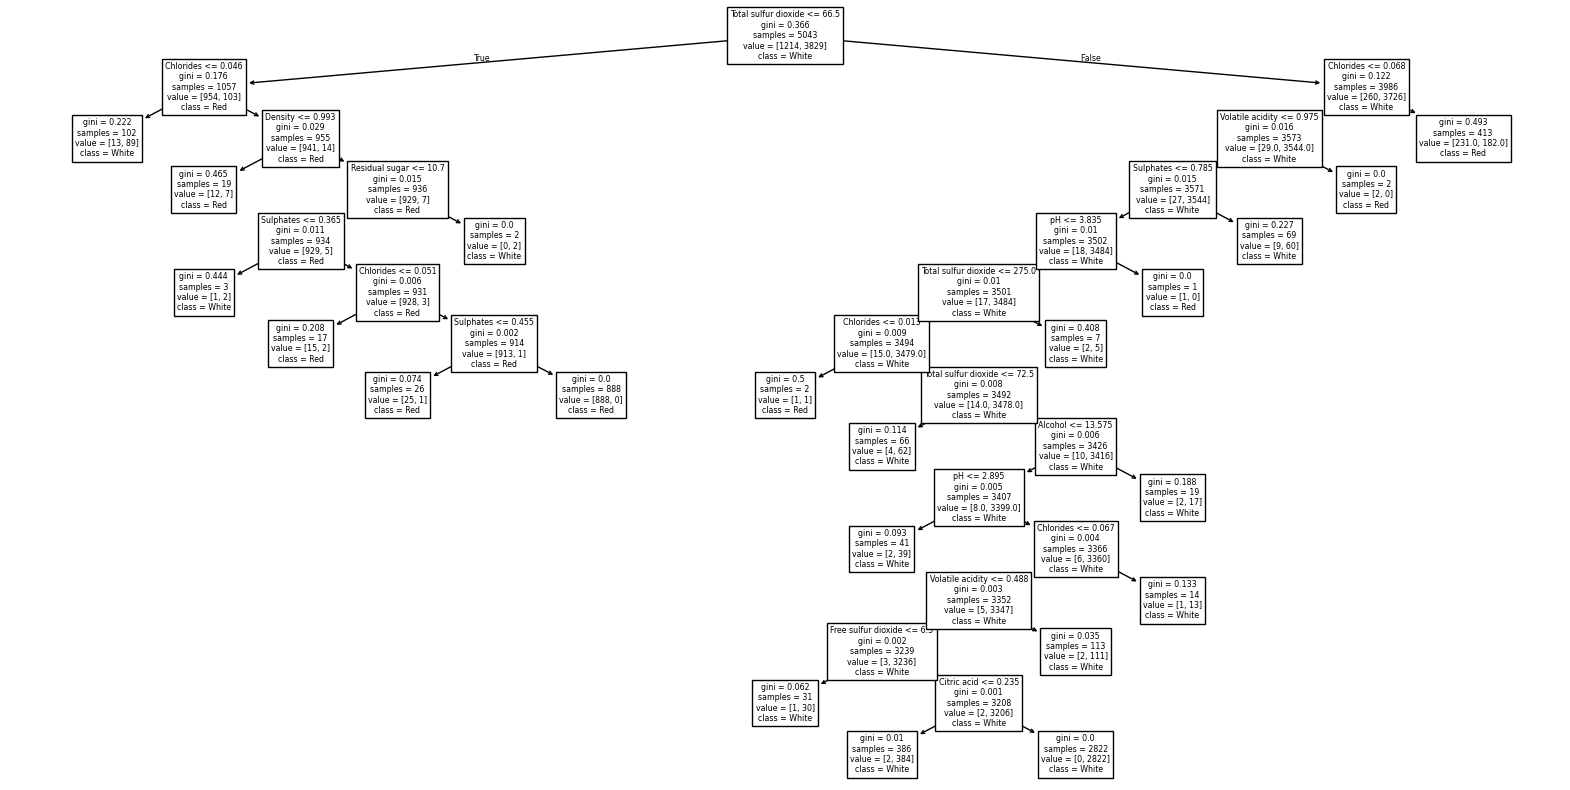

' When you make min_samples_split higner, the number of splits decreases, resulting in fewer nodes. '

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

dtc = tree.DecisionTreeClassifier(min_samples_split=500)
dtc = dtc.fit(X_train, Y_train)
plt.figure(figsize=(20,10))
tree.plot_tree(dtc, feature_names=attribute_names, class_names=class_names)
plt.show()

""" When you make min_samples_split higner, the number of splits decreases, resulting in fewer nodes. """

## Exercise 1.4

Show that a wine with the following attribute values would be classified as white by the tree fitted in 1.3, by applying the `predict()` function from the DecisionTreeClassifier to this sample.  Have another look at the visualized tree. Which attributes are used to classify this wine? You can use the `decision_path` function to specifically print the path for a certain sample. To relate the node id returned by `decision_path` to the tree plot, you can modify the tree plot using the `node_ids` argument.

| #             | Attribute     | Value  |
| ------------- |:-------------| -----:|
|1 | Fixed acidity (tartaric) | 6.9 g/dm$^3$ |
|2 | Volatile acidity (acetic) | 1.09 g/dm$^3$ |
|3 | Citric acid | 0.06 g/dm$^3$ |
|4 | Residual sugar | 2.1 g/dm$^3$ |
|5 | Chlorides | 0.0061 g/dm$^3$ |
|6 | Free sulfur dioxide | 12 mg/dm$^3$ |
|7 | Total sulfur dioxide | 31 mg/dm$^3$ |
|8 | Density | 0.99 g/cm$^3$ |
|9 | pH | 3.5 |
|10 | Sulphates | 0.64 g/dm$^3$ |
|11 | Alcohol | 12 % vol. |

**helpful hint:**
> If you don't know how to classify input values with a tree, see the help documentation for the DecisionTreeClassifier function on how to predict the label for a sample.

In [5]:
x_class = None
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

YOUR ANSWER HERE

## Exercise 1.5
Classify all the wines in the wine data set. What is the classification accuracy of the tree on the wine data? Save the accuracy (which should be a number between 0 and 1) to a variable called `accuracy` and print it.

Why is the accuracy we've calculated in this experiment not a good measure of the performance of our classifier on new data?


In [ ]:
accuracy_train = None

# YOUR CODE HERE
raise NotImplementedError()

## Exercise 1.6
In the exercise above we calculated the accuracy of our classifier on the training data. One way to give an estimation of the performance of our classifier on new data is to calculate the generalization error. Can you calculate the generalization error, using the optimistic and pessimistic approaches as described in Subsection 3.5.2 of TSKK.  Another way to more directly calculate the performance on new data is to use the test set. Calculate the accuracy of the classifier on the test set. Did the generalization error over-estimate or under-estimate the performance on new data?

In [ ]:
generalization_error_optimistic = None
generalization_error_pessimistic = None
accuracy_test = None

# YOUR CODE HERE
raise NotImplementedError()

## **Exercise 2** - Calculations

| Instance | a1 | a2 | a3 | Target Class |
|---|---|---|---|---|
| 1 | T | T | 1.0 | + |
| 2 | T | T | 6.0 | + |
| 3 | T | F | 5.0 | − |
| 4 | F | F | 4.0 | + |
| 5 | F | T | 7.0 | − |
| 6 | F | T | 3.0 | − |
| 7 | F | F | 8.0 | − |
| 8 | T | F | 7.0 | + |
| 9 | F | T | 5.0 | − |

Consider the training examples shown in Table 3.6 for a binary classification
problem.

a. What is the entropy of this collection of training examples with respect
to the class attribute?

b. What are the information gains of a1 and a2 relative to these training
examples?

c. For a3, which is a continuous attribute, compute the information gain for
every possible split.

d. What is the best split (among a1, a2, and a3) according to the information
gain?

e. What is the best split (between a1 and a2) according to the misclassifi-
cation error rate?

f. What is the best split (between a1 and a2) according to the Gini index?

**ANSWERS:**

#### a. 
Entropy of this collection is: $-(\frac{4}{9}*\log(\frac{4}{9}) + \frac{5}{9}*\log(\frac{5}{9})) = 0.991$  (Note: log base 2 is assumed.)

#### b.
__a1:__ First we calculate the entropy of both children (For True: 0.811 and for False: 0.722). Then we weigh them with their probabilities (4/9 and 5/9) and sum them => 0.763. In the end we need to calculate the difference between the parent node and the children nodes: 0.991 - 0.763 = **0.228**.\
__a2:__ Using the same principle we get gain: __0.007__.

#### c. 
I will use the efficient method, where you first sort the values: 1.0, 3.0, 4.0, 5.0, 5.0, 6.0, 7.0, 7.0, 8.0. First we won't calculate the gain at 7.0, because the class label changes there. We find the thresholds: 2.0, 3.5, 4.5, 5.6, 7.5. Left of the label 2.0 is 1 + and 0 -. Right of the label are 3 + and 5 -. So the entropy(t_2.0) = -(1/9 * 1/1 * log(1) + 8/9 * (3/8 * log(3/8) + 5/8 * log(5/8))) = 0.848. To get information gain: 0.991 - 0.848 = **0.142**.
For the other ones we do the same, but this is the best one.

#### d. 
Best split is __a1__, since it has the biggest gain.

#### e.
Error(t) = 1 - 5/9 = 4/9 = 0.444\
Error(t_a1) = 5/9*(1 - 4/5) + 4/9*(1 - 3/4)= 0.222\
Error(t_a2) = 5/9(1 - 3/5) + 4/9(1 - 0.5) = 0.444\
This means that a1 is best split between a1 and a2 because the misclassification error is smaller.

#### f.
GINI(t_a1) = 5/9*(1 - (1/5)^2 - (4/5)^2) + 4/9*(1 - (1/4)^2 - (3/4)^2) = 0.345\
GINI(t_a2) = $\ldots$ = 0.488\
This means that a1 is once again the best split between a1 and a2, because the GINI index of a1 is smaller.


*Note to self:* So we are at node t now still with 9 training examples and we want to make the best split possible comparing the collective impurity of child nodes with different splits.

## **Exercise 3** - Greedy Trees

| A | B | C | Number of Instances (+) | Number of Instances (-) |
|:---:|:---:|:---:|:---:|:---:|
| T | T | T | 5 | 0 |
| F | T | T | 0 | 20 |
| T | F | T | 20 | 0 |
| F | F | T | 0 | 5 |
| T | T | F | 0 | 0 |
| F | T | F | 25 | 0 |
| T | F | F | 0 | 0 |
| F | F | F | 0 | 25 |

a. According to the classification error rate, which attribute would be chosen
as the first splitting attribute? For each attribute, show the contingency
table and the gains in classification error rate.

b. Repeat for the two children of the root node.

c. How many instances are misclassified by the resulting decision tree?

d. Repeat parts (a), (b), and (c) using C as the splitting attribute.

e. Use the results in parts (c) and (d) to conclude about the greedy nature of the decision tree induction algorithm.

YOUR ANSWERS HERE

## **Exercise 4** - Error Rates
Consider the decision tree you made in 3.d (the previous exercise)

a. Compute the generalization error rate of the tree using the optimistic
approach.

b. Compute the generalization error rate of the tree using the pessimistic
approach. (For simplicity, use the strategy of adding a factor of 0.5 to
each leaf node.)

| A | B | C | Value |
|:---:|:---:|:---:|:---:
| T | T | T | - |
| F | T | T | -|
| T | F | T | + |
| F | F | T | -|
| F | T | F | + |
| F | F | F | - |
| F | T | F | + |
| F | F | F | - |

c. Compute the generalization error rate of the tree using the validation set
shown above. This approach is known as reduced error pruning.

YOUR ANSWERS HERE

## **Exercise 5** - MDL
Consider the decision trees shown in Figure 3.37. Assume they are generated
from a data set that contains 32 binary attributes and 4 classes, C1, C2, C3
and C4.

Compute the total description length of each decision tree according to the
following formulation of the minimum description length principle.
* The total description length of a tree is given by
Cost(tree, data) = Cost(tree) + Cost(data|tree).
* Each internal node of the tree is encoded by the ID of the splitting
attribute. If there are m attributes, the cost of encoding each attribute is
$\log_2 m$ bits.
* Each leaf is encoded using the ID of the class it is associated with. If there
are k classes, the cost of encoding a class is $log_2 k$ bits.
* Cost(tree) is the cost of encoding all the nodes in the tree. To simplify the
computation, you can assume that the total cost of the tree is obtained
by adding up the costs of encoding each internal node and each leaf node.
* Cost(data|tree) is encoded using the classification errors the tree commits
on the training set. Each error is encoded by $log_2 n$ bits, where n is the
total number of training instances.

Which decision tree is better, according to the MDL principle?

YOUR ANSWER HERE

# **Part B**

# Handing in
Hand in the filled-in notebook:
- Make sure your names and student-numbers are mentioned at the appropriate location at the top of this file.
- Make sure you wrote a serious attempt for all exercises in part A
- Make sure the notebook is named groupnumber_assignment1.ipynb

When you are confident all of this is correctly done, one of you can hand in the exercises in Brightspace!